# 04 — Exploratory Data Analysis

Attrition exploration and candidate driver analysis.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

In [2]:
from modules.io.datasets import load_ibm_hr_dataset
from modules.eda.attrition import (
    attrition_rate_by_category,
    attrition_rate_by_numeric_bins
)
from modules.eda.correlations import (
    numeric_correlation_matrix,
    target_numeric_correlation
)
from modules.eda.visualization import (
    plot_target_distribution,
    plot_attrition_by_category,
    plot_correlation_heatmap
)

df = load_ibm_hr_dataset()
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


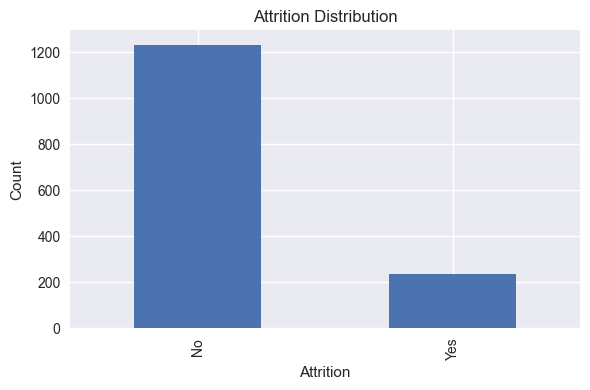

In [3]:
plot_target_distribution(df)

In [4]:
attrition_rate_by_category(df, 'Department')

,Department,attrition_rate_pct,count
0,Sales,20.627803,446
1,Human Resources,19.047619,63
2,Research & Development,13.839750,961


In [5]:
attrition_rate_by_category(df, 'JobRole')

,JobRole,attrition_rate_pct,count
0,Sales Representative,39.759036,83
1,Laboratory Technician,23.938224,259
2,Human Resources,23.076923,52
3,Sales Executive,17.484663,326
4,Research Scientist,16.095890,292
5,Manufacturing Director,6.896552,145
6,Healthcare Representative,6.870229,131
7,Manager,4.901961,102
8,Research Director,2.500000,80


In [6]:
attrition_rate_by_category(df, 'OverTime')

,OverTime,attrition_rate_pct,count
0,Yes,30.528846,416
1,No,10.436433,1054


In [7]:
attrition_rate_by_numeric_bins(df, 'MonthlyIncome')

,MonthlyIncome_bin,attrition_rate_pct,count
0,"(1008.999, 2695.8]",31.292517,294
1,"(2695.8, 4228.8]",17.006803,294
2,"(5743.4, 9860.0]",12.585034,294
3,"(4228.8, 5743.4]",10.544218,294
4,"(9860.0, 19999.0]",9.183673,294


In [8]:
target_numeric_correlation(df)

,feature,correlation
0,TotalWorkingYears,-0.171063
1,JobLevel,-0.169105
2,YearsInCurrentRole,-0.160545
3,MonthlyIncome,-0.159840
4,Age,-0.159205
5,YearsWithCurrManager,-0.156199
6,StockOptionLevel,-0.137145
7,YearsAtCompany,-0.134392
8,JobInvolvement,-0.130016
9,JobSatisfaction,-0.103481


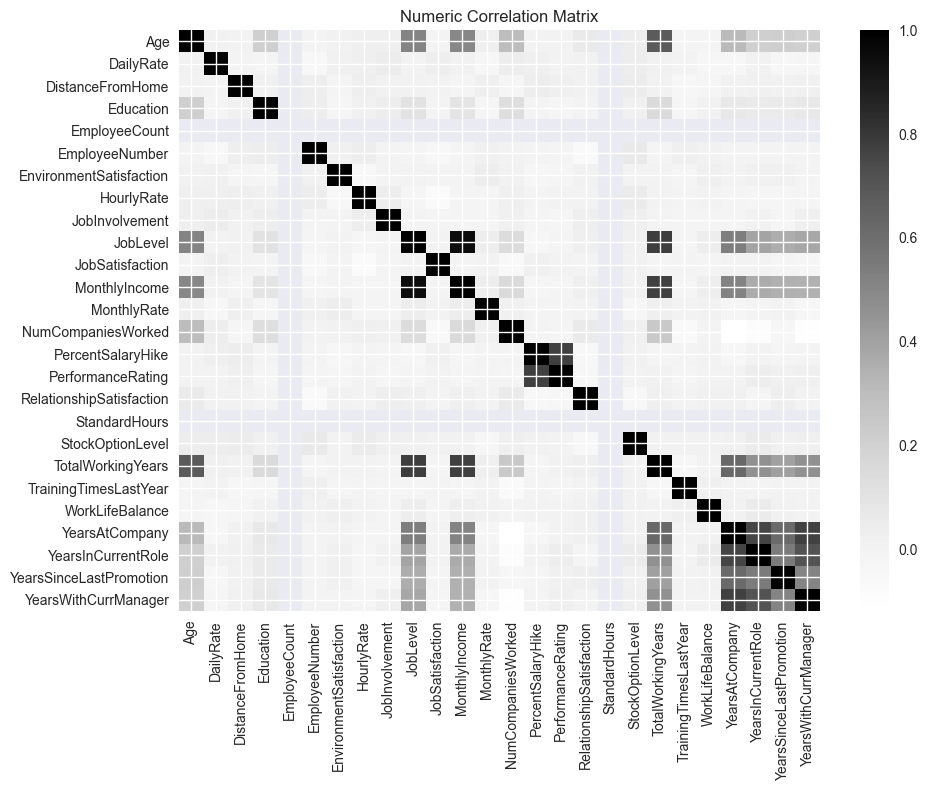

In [9]:
corr = numeric_correlation_matrix(df)
plot_correlation_heatmap(corr)